# Field Line Directional Derivatives Guide - 9 Key Formulas


This notebook demonstrates the usage, performance, and accuracy of a *vectorized* directional derivative implementation

that focuses on the **9 key formulas** for magnetic field line geometry in the `geopack` vectorized utilities.


**Markdown structure/style** is aligned with (①), while the **coding style** (wrappers, modular helpers, explicit module usage)

is aligned with (②).


## Table of Contents

1. [Introduction](#introduction)

2. [Mathematical Background](#mathematical-background)

3. [Basic Usage](#basic-usage)

4. [Performance Benchmarks](#performance-benchmarks)

5. [Accuracy Validation](#accuracy-validation)

6. [Practical Applications](#practical-applications)

7. [Limitations and Considerations](#limitations)

In [1]:
import time
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

# 3D plotting
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# --- geopack core ---
from geopack import recalc, dip

# --- optional: external model (T96) ---
# If your environment has T96 vectorized wrapper like in (①), use it.
# Otherwise, you can switch to the "dipole" model below for a minimal runnable path.
try:
    from geopack import t96_vectorized  # (parmod, ps, x, y, z) -> (Bx, By, Bz)
except Exception:
    t96_vectorized = None

# --- vectorized geometry & directional derivative modules (style like ②) ---
from geopack.vectorized.field_line_geometry import (
    field_line_curvature,
    field_line_torsion,
    field_line_geometry_complete,
)

from geopack.vectorized.field_line_directional_derivatives import (
    field_line_directional_derivatives,
    verify_antisymmetry_relations,
    get_curvature_torsion_from_derivatives,
    verify_unit_vectors,
)



Load IGRF coefficients ...


<a id='introduction'></a>

## 1. Introduction


The `field_line_directional_derivatives(...)` function computes the **9 key directional derivative formulas**

that describe how the Frenet-Serret frame vectors (tangent **T**, normal **n**, and binormal **b**) change

along magnetic field lines.


### The 9 Key Formulas:

1. **(∂T/∂T)·n = κ** (curvature)

2. **(∂T/∂T)·b = 0**

3. **(∂n/∂T)·b = τ** (torsion)

4. **(∂T/∂n)·n**

5. **(∂T/∂n)·b**

6. **(∂n/∂n)·b**

7. **(∂n/∂b)·b**

8. **(∂n/∂b)·T**

9. **(∂b/∂b)·T**


These formulas satisfy antisymmetry relations:

If **(∂A/∂B)·C = value**, then **(∂C/∂B)·A = -value**.


---


**Implementation note (aligned with ②):**

- We use *model wrappers* with a unified signature: `(parmod, ps, x, y, z) -> (Bx, By, Bz)`.

- We call geometry/derivative routines from:

  - `geopack.vectorized.field_line_geometry`

  - `geopack.vectorized.field_line_directional_derivatives`

In [2]:
# -----------------------------
# Model selection / parameters
# -----------------------------
MODEL = "t96"  # "t96" or "dipole"

# Time / tilt
ut = datetime(2023, 3, 15, 12, 0, 0).timestamp()
ps = recalc(ut)

# T96 parameters (only used if MODEL=="t96")
Pdyn = 2.0    # Solar wind dynamic pressure (nPa)
Dst = -20     # Dst index (nT)
ByIMF = 0.0   # IMF By (nT)
BzIMF = -5.0  # IMF Bz (nT)
parmod_t96 = [Pdyn, Dst, ByIMF, BzIMF, 0, 0, 0, 0, 0, 0]

print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")
if MODEL == "t96":
    if t96_vectorized is None:
        raise ImportError("MODEL='t96' was selected, but t96_vectorized could not be imported in this environment.")
    parmod = parmod_t96
    print(f"Model: T96 | Pdyn={Pdyn} nPa, Dst={Dst} nT, By={ByIMF} nT, Bz={BzIMF} nT")
else:
    parmod = None
    print("Model: Dipole | parmod ignored")



Dipole tilt angle: -10.30 degrees
Model: T96 | Pdyn=2.0 nPa, Dst=-20 nT, By=0.0 nT, Bz=-5.0 nT


In [3]:
# %%
# -----------------------------
# Model selection / parameters
# -----------------------------
# Options:
#   "dip"       : internal(dip) only
#   "t96"       : external(t96) only
#   "t96+dip"   : external(t96) + internal(dip)
MODEL = "t96+dip"

# Time / tilt
ut = datetime(2023, 3, 15, 12, 0, 0).timestamp()
ps = recalc(ut)

# T96 parameters (external model)
Pdyn = 2.0    # nPa
Dst = -20     # nT
ByIMF = 0.0   # nT
BzIMF = -5.0  # nT
parmod_t96 = [Pdyn, Dst, ByIMF, BzIMF, 0, 0, 0, 0, 0, 0]

print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")


# %%
# -----------------------------
# Model wrappers (external + internal)
# -----------------------------
def dipole_internal_wrapper(parmod, ps, x, y, z):
    """
    internal field: dipole
    NOTE: dip() only accepts (x,y,z), so parmod and ps are ignored (kept for unified signature)
    """
    return dip(x, y, z)


def t96_external_wrapper(parmod, ps, x, y, z):
    """
    external field: T96 (vectorized)
    """
    if t96_vectorized is None:
        raise ImportError("T96 wrapper (t96_vectorized) is not available in this environment.")
    if parmod is None:
        raise ValueError("parmod must be provided for T96 external field.")
    return t96_vectorized(parmod, ps, x, y, z)


def combined_field_wrapper(
    parmod, ps, x, y, z,
    use_external=True,
    use_internal=True,
):
    """
    Combined field:
      B_total = (use_external ? B_t96 : 0) + (use_internal ? B_dip : 0)

    Works with both scalar and array inputs by using np.asarray + zeros_like as a placeholder.
    """
    x_arr = np.asarray(x)
    Bx = np.zeros_like(x_arr, dtype=float)
    By = np.zeros_like(x_arr, dtype=float)
    Bz = np.zeros_like(x_arr, dtype=float)

    if use_external:
        bx, by, bz = t96_external_wrapper(parmod, ps, x, y, z)
        Bx = Bx + np.asarray(bx)
        By = By + np.asarray(by)
        Bz = Bz + np.asarray(bz)

    if use_internal:
        bx, by, bz = dipole_internal_wrapper(parmod, ps, x, y, z)
        Bx = Bx + np.asarray(bx)
        By = By + np.asarray(by)
        Bz = Bz + np.asarray(bz)

    return Bx, By, Bz


# %%
# -----------------------------
# Final MODEL_FUNC selection
# -----------------------------
if MODEL == "dip":
    parmod = None
    MODEL_FUNC = lambda parmod, ps, x, y, z: combined_field_wrapper(
        parmod, ps, x, y, z, use_external=False, use_internal=True
    )
    print("Model: internal(dip) only")

elif MODEL == "t96":
    parmod = parmod_t96
    MODEL_FUNC = lambda parmod, ps, x, y, z: combined_field_wrapper(
        parmod, ps, x, y, z, use_external=True, use_internal=False
    )
    print(f"Model: external(T96) only | Pdyn={Pdyn} nPa, Dst={Dst} nT, By={ByIMF} nT, Bz={BzIMF} nT")

elif MODEL == "t96+dip":
    parmod = parmod_t96
    MODEL_FUNC = lambda parmod, ps, x, y, z: combined_field_wrapper(
        parmod, ps, x, y, z, use_external=True, use_internal=True
    )
    print(f"Model: external(T96) + internal(dip) | Pdyn={Pdyn} nPa, Dst={Dst} nT, By={ByIMF} nT, Bz={BzIMF} nT")

else:
    raise ValueError(f"Unknown MODEL: {MODEL}")


Dipole tilt angle: -10.30 degrees
Model: external(T96) + internal(dip) | Pdyn=2.0 nPa, Dst=-20 nT, By=0.0 nT, Bz=-5.0 nT


In [4]:
# -----------------------------
# Small utilities (merged feel)
# -----------------------------
def get_max_antisymmetry_error(derivatives_dict):
    """Return max antisymmetry error (works for scalars/arrays)."""
    errs = verify_antisymmetry_relations(derivatives_dict)
    max_list = []
    for _, e in errs.items():
        if hasattr(e, "shape"):
            max_list.append(np.nanmax(np.abs(e)))
        else:
            max_list.append(abs(e))
    return float(np.nanmax(max_list))


def compute_geometry(model_func, parmod, ps, x, y, z, delta=1e-2):
    """Compute Frenet frame + curvature/torsion using field_line_geometry_complete."""
    tx, ty, tz, nx, ny, nz, bx, by, bz, kappa, tau = field_line_geometry_complete(
        model_func, parmod, ps, x, y, z, delta=delta
    )
    return {
        "tx": tx, "ty": ty, "tz": tz,
        "nx": nx, "ny": ny, "nz": nz,
        "bx": bx, "by": by, "bz": bz,
        "kappa": kappa, "tau": tau,
    }


def compute_derivatives(model_func, parmod, ps, x, y, z, delta=1e-2):
    """Compute full directional derivatives dictionary."""
    return field_line_directional_derivatives(model_func, parmod, ps, x, y, z, delta=delta)



<a id='mathematical-background'></a>

## 2. Mathematical Background


### Frenet-Serret Frame

For a space curve (magnetic field line), the Frenet-Serret frame consists of orthonormal unit vectors:

- **T**: Unit tangent vector (along the field line), |T| = 1

- **n**: Unit principal normal vector (points toward center of curvature), |n| = 1

- **b**: Unit binormal vector (**b** = **T** × **n**), |b| = 1


These vectors satisfy:

- T·T = n·n = b·b = 1 (unit vectors)

- T·n = T·b = n·b = 0 (orthogonal)


### Frenet-Serret Formulas

The derivatives with respect to arc length s are:

- d**T**/ds = κ**n**

- d**n**/ds = -κ**T** + τ**b**

- d**b**/ds = -τ**n**


where κ is the curvature and τ is the torsion.


### Key Properties for Unit Vectors

Since T, n, and b are unit vectors:

1. **Self-perpendicularity**: The derivative of a unit vector is perpendicular to itself

   - (∂T/∂s)·T = 0 for any direction s

   - (∂n/∂s)·n = 0 for any direction s

   - (∂b/∂s)·b = 0 for any direction s

2. **Antisymmetry**: If (∂A/∂B)·C = value, then (∂C/∂B)·A = -value


The 9 formulas capture all non-zero components while respecting these constraints.

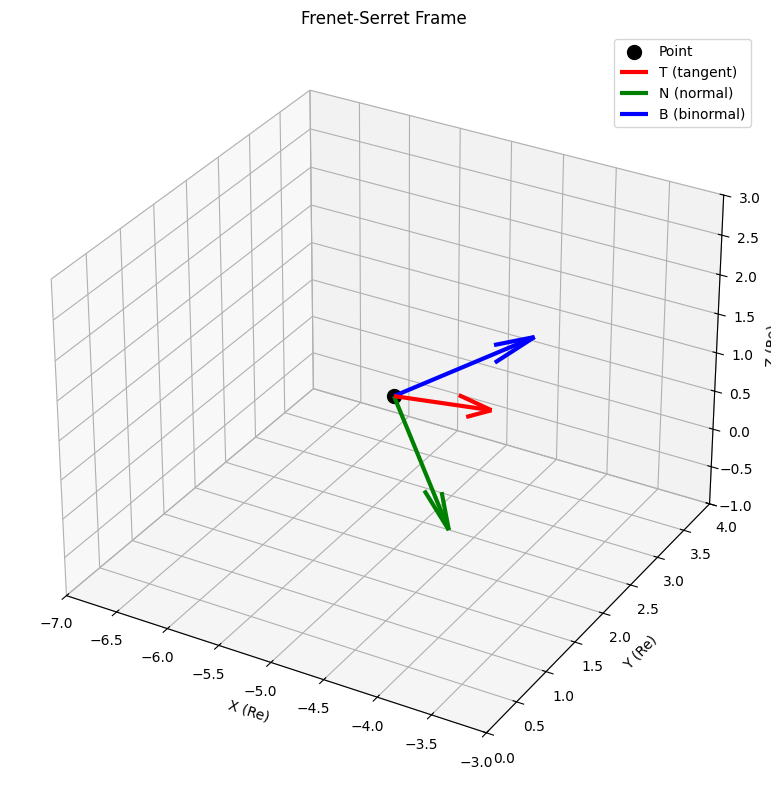

Orthonormality check:
|T| - 1    = 0.000e+00 (should be ~0)
|n| - 1    = 2.220e-16 (should be ~0)
|b| - 1    = 6.676e-12 (should be ~0)
T·n        = 3.654e-06 (should be ~0)
T·b        = 6.939e-18 (should be ~0)
n·b        = 0.000e+00 (should be ~0)
b - T×n    = 0.000e+00 (should be ~0)

Curvature at this point: 0.125942 1/Re


In [5]:
# Visualize the Frenet-Serret frame at a point (like ①)
x0, y0, z0 = -5.0, 2.0, 1.0
delta0 = 1e-2

geo = compute_geometry(MODEL_FUNC, parmod, ps, x0, y0, z0, delta=delta0)

tx, ty, tz = geo["tx"], geo["ty"], geo["tz"]
nx, ny, nz = geo["nx"], geo["ny"], geo["nz"]
bx, by, bz = geo["bx"], geo["by"], geo["bz"]
curv = geo["kappa"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter([x0], [y0], [z0], c="black", s=100, label="Point")

scale = 1.5
ax.quiver(x0, y0, z0, tx * scale, ty * scale, tz * scale,
          color="red", arrow_length_ratio=0.3, linewidth=3, label="T (tangent)")
ax.quiver(x0, y0, z0, nx * scale, ny * scale, nz * scale,
          color="green", arrow_length_ratio=0.3, linewidth=3, label="N (normal)")
ax.quiver(x0, y0, z0, bx * scale, by * scale, bz * scale,
          color="blue", arrow_length_ratio=0.3, linewidth=3, label="B (binormal)")

ax.set_xlabel("X (Re)")
ax.set_ylabel("Y (Re)")
ax.set_zlabel("Z (Re)")
ax.set_title("Frenet-Serret Frame")
ax.legend()

max_range = 2
ax.set_xlim([x0 - max_range, x0 + max_range])
ax.set_ylim([y0 - max_range, y0 + max_range])
ax.set_zlim([z0 - max_range, z0 + max_range])

plt.tight_layout()
plt.show()

# Verify orthonormality (style like ② via verify_unit_vectors)
unit_errs = verify_unit_vectors(tx, ty, tz, nx, ny, nz, bx, by, bz)
print("Orthonormality check:")
for k, v in unit_errs.items():
    print(f"{k:10s} = {float(np.max(np.abs(v))):.3e} (should be ~0)")
print(f"\nCurvature at this point: {float(curv):.6f} 1/Re")



<a id='basic-usage'></a>

## 3. Basic Usage


Let's demonstrate how to use the directional derivative functions.

In [6]:
# Single point calculation
x, y, z = -5.0, 0.0, 0.0
delta = 1e-2

derivatives = compute_derivatives(MODEL_FUNC, parmod, ps, x, y, z, delta=delta)

print("Directional Derivatives at ({:.1f}, {:.1f}, {:.1f}) Re:".format(x, y, z))
print("=" * 60)

print("\nThe 9 Key Formulas:")
print("-" * 40)
print("\n1. Tangential derivatives (Frenet-Serret):")
print(f"   (∂T/∂T)·n = {float(derivatives['dT_dT_n']):8.5f}  (curvature κ)")
print(f"   (∂T/∂T)·b = {float(derivatives['dT_dT_b']):8.5f}  (should be 0)")
print(f"   (∂n/∂T)·b = {float(derivatives['dn_dT_b']):8.5f}  (torsion τ)")

print("\n2. Normal derivatives:")
print(f"   (∂T/∂n)·n = {float(derivatives['dT_dn_n']):8.5f}")
print(f"   (∂T/∂n)·b = {float(derivatives['dT_dn_b']):8.5f}")
print(f"   (∂n/∂n)·b = {float(derivatives['dn_dn_b']):8.5f}")

print("\n3. Binormal derivatives:")
print(f"   (∂n/∂b)·b = {float(derivatives['dn_db_b']):8.5f}")
print(f"   (∂n/∂b)·T = {float(derivatives['dn_db_T']):8.5f}")
print(f"   (∂b/∂b)·T = {float(derivatives['db_db_T']):8.5f}")

# Compare κ, τ with geometry module (style like ②)
kappa_from_der, tau_from_der = get_curvature_torsion_from_derivatives(derivatives)

kappa_std = field_line_curvature(MODEL_FUNC, parmod, ps, x, y, z, delta=delta)
tau_std = field_line_torsion(MODEL_FUNC, parmod, ps, x, y, z, delta=delta)

print("\n" + "=" * 60)
print("Comparison with geometry module:")
print(f"Curvature from derivatives: {float(kappa_from_der):.6f}")
print(f"Curvature from geometry:    {float(kappa_std):.6f}")
print(f"Torsion from derivatives:   {float(tau_from_der):.6f}")
print(f"Torsion from geometry:      {float(tau_std):.6f}")



Directional Derivatives at (-5.0, 0.0, 0.0) Re:

The 9 Key Formulas:
----------------------------------------

1. Tangential derivatives (Frenet-Serret):
   (∂T/∂T)·n =  0.46797  (curvature κ)
   (∂T/∂T)·b =  0.00000  (should be 0)
   (∂n/∂T)·b = -0.00000  (torsion τ)

2. Normal derivatives:
   (∂T/∂n)·n = -0.52683
   (∂T/∂n)·b = -0.00000
   (∂n/∂n)·b =  0.00000

3. Binormal derivatives:
   (∂n/∂b)·b = -0.14245
   (∂n/∂b)·T =  0.00000
   (∂b/∂b)·T =  0.13837

Comparison with geometry module:
Curvature from derivatives: 0.467972
Curvature from geometry:    0.467972
Torsion from derivatives:   -0.000000
Torsion from geometry:      -0.000000


Antisymmetry validation:
--------------------------------------------------
κ_check                max error =   2.83e-05  ✓ PASS
τ_check                max error =   1.11e-23  ✓ PASS
zero_check_1           max error =   9.24e-22  ✓ PASS
dT_dn_n_check          max error =   2.35e-05  ✓ PASS
dT_dn_b_check          max error =   1.30e-17  ✓ PASS
dn_dn_b_check          max error =   5.99e-20  ✓ PASS
dn_db_b_check          max error =   4.23e-07  ✓ PASS
dn_db_T_check          max error =   5.21e-11  ✓ PASS
db_db_T_check          max error =   6.69e-07  ✓ PASS


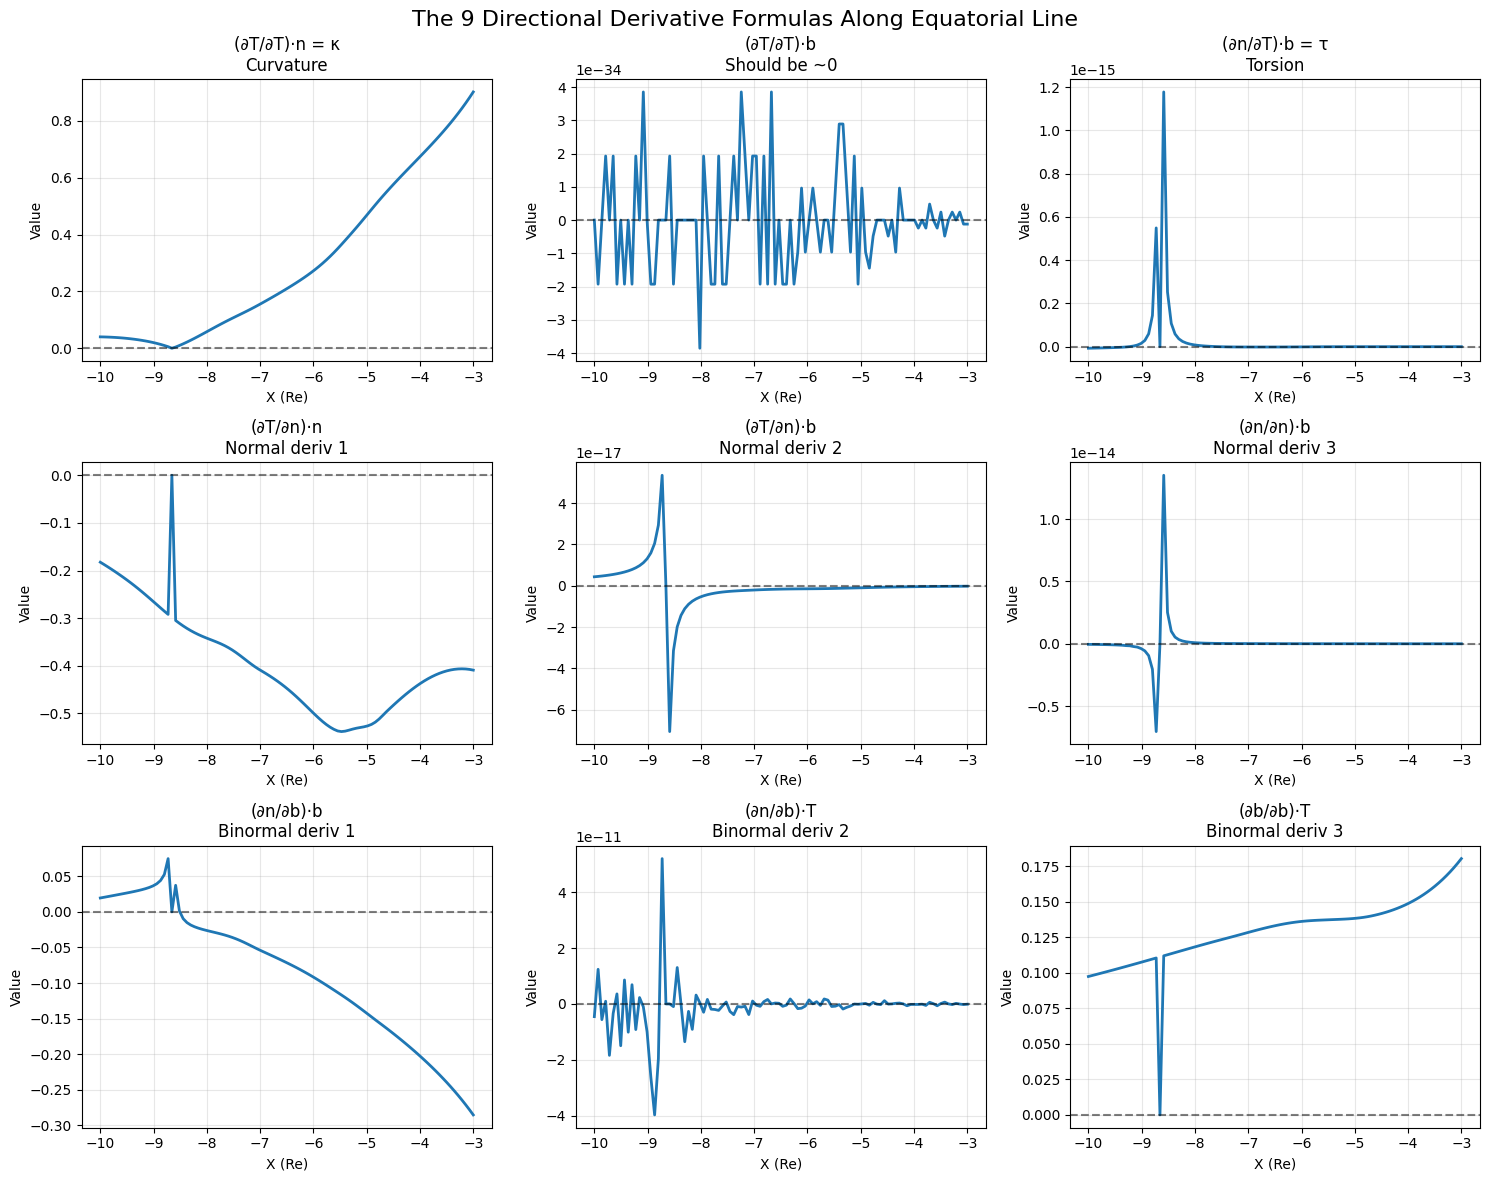

In [7]:
# Array calculation example
x_arr = np.linspace(-10, -3, 100)
y_arr = np.zeros_like(x_arr)
z_arr = np.zeros_like(x_arr)

derivatives_arr = compute_derivatives(MODEL_FUNC, parmod, ps, x_arr, y_arr, z_arr, delta=delta)

# Verify antisymmetry relations
errors = verify_antisymmetry_relations(derivatives_arr)

print("Antisymmetry validation:")
print("-" * 50)
for name, error in errors.items():
    max_error = np.nanmax(np.abs(error)) if hasattr(error, "__len__") else abs(error)
    status = "✓ PASS" if max_error < 1e-4 else "✗ FAIL"
    print(f"{name:22} max error = {max_error:10.2e}  {status}")

# Visualize the 9 formulas along the line
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("The 9 Directional Derivative Formulas Along Equatorial Line", fontsize=16)

plots = [
    (derivatives_arr["dT_dT_n"], "(∂T/∂T)·n = κ", "Curvature"),
    (derivatives_arr["dT_dT_b"], "(∂T/∂T)·b", "Should be ~0"),
    (derivatives_arr["dn_dT_b"], "(∂n/∂T)·b = τ", "Torsion"),
    (derivatives_arr["dT_dn_n"], "(∂T/∂n)·n", "Normal deriv 1"),
    (derivatives_arr["dT_dn_b"], "(∂T/∂n)·b", "Normal deriv 2"),
    (derivatives_arr["dn_dn_b"], "(∂n/∂n)·b", "Normal deriv 3"),
    (derivatives_arr["dn_db_b"], "(∂n/∂b)·b", "Binormal deriv 1"),
    (derivatives_arr["dn_db_T"], "(∂n/∂b)·T", "Binormal deriv 2"),
    (derivatives_arr["db_db_T"], "(∂b/∂b)·T", "Binormal deriv 3"),
]

for idx, (data, formula, title) in enumerate(plots):
    ax = axes[idx // 3, idx % 3]
    ax.plot(x_arr, data, linewidth=2)
    ax.set_xlabel("X (Re)")
    ax.set_ylabel("Value")
    ax.set_title(f"{formula}\n{title}")
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color="k", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



<a id='performance-benchmarks'></a>

## 4. Performance Benchmarks


Let's compare the performance of **looped (scalar-like)** vs **vectorized** calculations.

Performance Benchmark Results:
N Points   Looped (s)     Vector (s)     Speedup   
----------------------------------------------------------------------
10         18.7424        1.9341         9.7       x
50         86.7109        2.4397         35.5      x
100        121.3467       0.8795         138.0     x


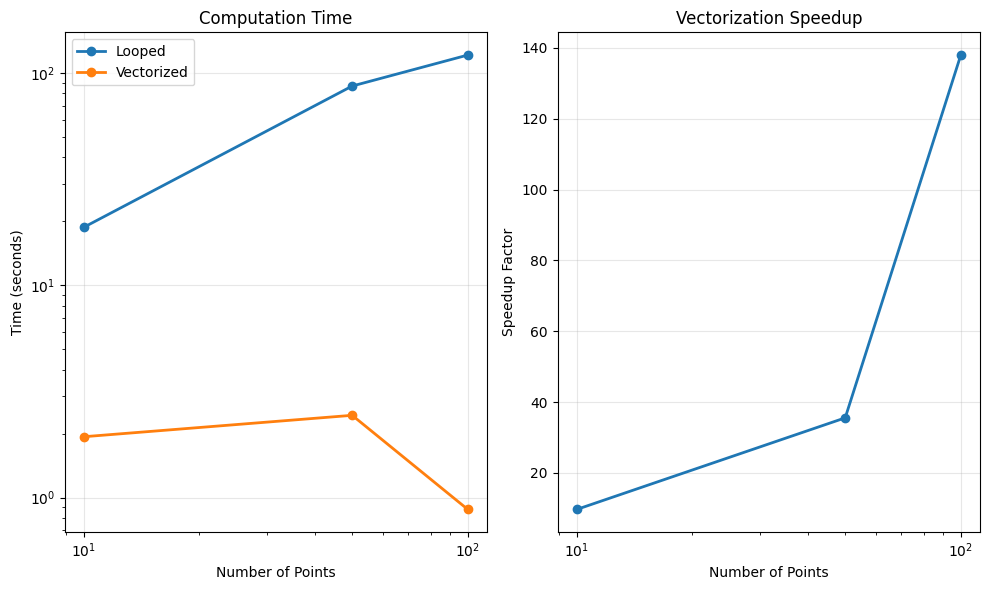

In [8]:
def benchmark_directional_derivatives(model_func, parmod, ps, n_points, delta=1e-2, seed=0):
    """Benchmark looped calls vs vectorized call; validate a few keys match."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-10, -3, n_points)
    y = rng.uniform(-3, 3, n_points)
    z = rng.uniform(-2, 2, n_points)

    # Looped (scalar-like)
    t0 = time.time()
    scalar_results = []
    for i in range(n_points):
        scalar_results.append(compute_derivatives(model_func, parmod, ps, x[i], y[i], z[i], delta=delta))
    scalar_time = time.time() - t0

    # Vectorized
    t0 = time.time()
    vector_results = compute_derivatives(model_func, parmod, ps, x, y, z, delta=delta)
    vector_time = time.time() - t0

    # Verify a few keys match
    keys_check = ["dT_dT_n", "dn_dT_b", "dT_dn_n"]
    for key in keys_check:
        scalar_vals = np.array([scalar_results[i][key] for i in range(n_points)])
        vector_vals = np.array(vector_results[key])
        max_diff = np.max(np.abs(scalar_vals - vector_vals))
        if not (max_diff < 1e-10):
            raise AssertionError(f"Results don't match for {key}! Max diff: {max_diff:.3e}")

    return scalar_time, vector_time


sizes = [10, 50, 100]
scalar_times = []
vector_times = []

print("Performance Benchmark Results:")
print("=" * 70)
print(f"{'N Points':<10} {'Looped (s)':<14} {'Vector (s)':<14} {'Speedup':<10}")
print("-" * 70)

for n in sizes:
    s_time, v_time = benchmark_directional_derivatives(MODEL_FUNC, parmod, ps, n, delta=delta, seed=42)
    scalar_times.append(s_time)
    vector_times.append(v_time)
    speedup = s_time / max(v_time, 1e-16)
    print(f"{n:<10} {s_time:<14.4f} {v_time:<14.4f} {speedup:<10.1f}x")

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.loglog(sizes, scalar_times, marker="o", linewidth=2, label="Looped")
plt.loglog(sizes, vector_times, marker="o", linewidth=2, label="Vectorized")
plt.xlabel("Number of Points")
plt.ylabel("Time (seconds)")
plt.title("Computation Time")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
speedups = np.array(scalar_times) / np.maximum(np.array(vector_times), 1e-16)
plt.semilogx(sizes, speedups, marker="o", linewidth=2)
plt.xlabel("Number of Points")
plt.ylabel("Speedup Factor")
plt.title("Vectorization Speedup")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



<a id='accuracy-validation'></a>

## 5. Accuracy Validation


Let's validate the key mathematical properties of the directional derivatives.

Mathematical Properties Validation:

Antisymmetry Relations (all should be ~0):
----------------------------------------
κ_check                max =   1.22e-03, mean =   5.62e-05
τ_check                max =   9.61e-06, mean =   2.01e-07
zero_check_1           max =   5.17e-06, mean =   3.67e-07
dT_dn_n_check          max =   2.35e-04, mean =   2.33e-05
dT_dn_b_check          max =   6.33e-04, mean =   1.34e-05
dn_dn_b_check          max =   9.07e-06, mean =   4.28e-07
dn_db_b_check          max =   1.90e-05, mean =   2.58e-07
dn_db_T_check          max =   6.59e-04, mean =   6.84e-06
db_db_T_check          max =   6.73e-04, mean =   3.95e-06

(∂T/∂T)·b statistics:
  Max abs value:  6.59e-17
  Mean abs value: 6.84e-18

Curvature comparison:
  Max difference: 4.44e-16
  Max relative error: 3.23e-16


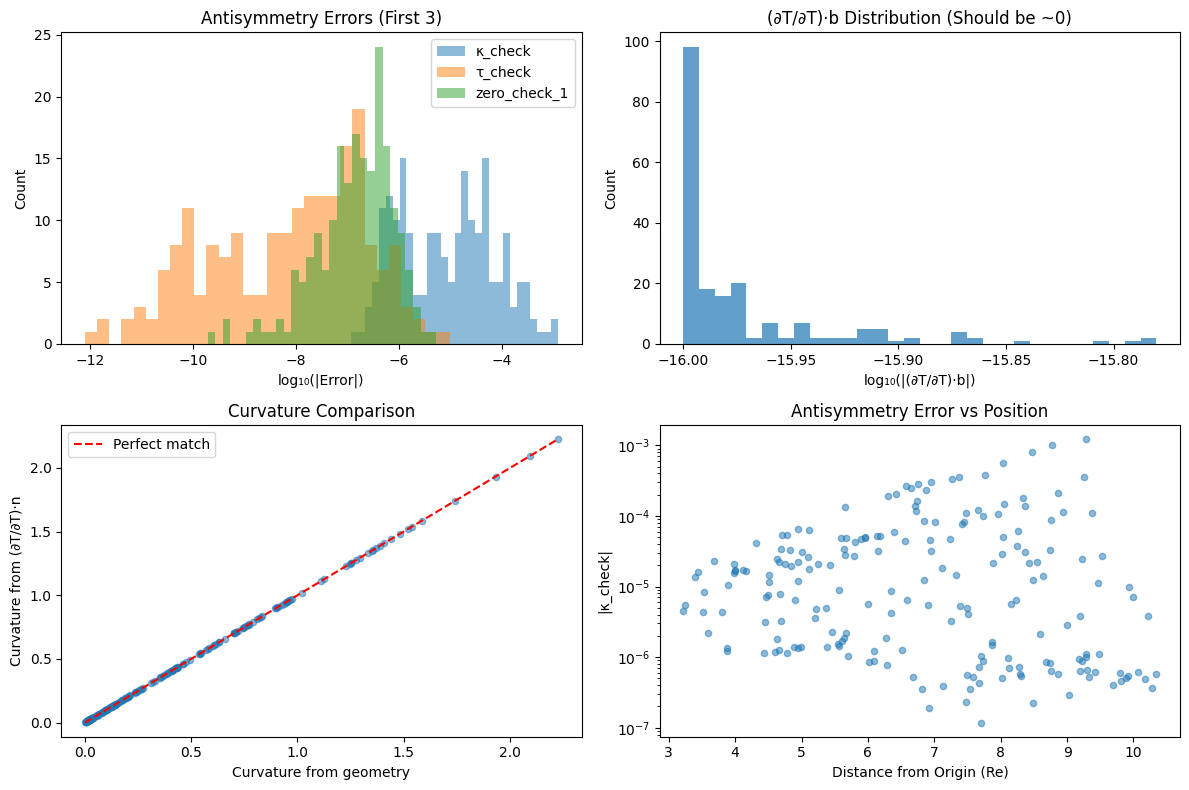

In [9]:
# Test mathematical properties at multiple points
n_test = 200
rng = np.random.default_rng(1)
x_test = rng.uniform(-10, -3, n_test)
y_test = rng.uniform(-3, 3, n_test)
z_test = rng.uniform(-2, 2, n_test)

derivatives = compute_derivatives(MODEL_FUNC, parmod, ps, x_test, y_test, z_test, delta=delta)
errors = verify_antisymmetry_relations(derivatives)

print("Mathematical Properties Validation:")
print("=" * 60)

print("\nAntisymmetry Relations (all should be ~0):")
print("-" * 40)
for name, error_array in errors.items():
    max_error = np.nanmax(np.abs(error_array))
    mean_error = np.nanmean(np.abs(error_array))
    print(f"{name:22} max = {max_error:10.2e}, mean = {mean_error:10.2e}")

print(f"\n(∂T/∂T)·b statistics:")
print(f"  Max abs value:  {np.nanmax(np.abs(derivatives['dT_dT_b'])):.2e}")
print(f"  Mean abs value: {np.nanmean(np.abs(derivatives['dT_dT_b'])):.2e}")

# Curvature match: derivatives vs geometry function
curv_from_deriv = np.array(derivatives["dT_dT_n"])
curv_standard = field_line_curvature(MODEL_FUNC, parmod, ps, x_test, y_test, z_test, delta=delta)
curv_standard = np.array(curv_standard)

curv_diff = curv_from_deriv - curv_standard
rel_err = np.abs(curv_diff) / (np.abs(curv_standard) + 1e-12)

print(f"\nCurvature comparison:")
print(f"  Max difference: {np.nanmax(np.abs(curv_diff)):.2e}")
print(f"  Max relative error: {np.nanmax(rel_err):.2e}")

# Visualize error distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Antisymmetry errors (first 3)
ax = axes[0, 0]
for name, error_array in list(errors.items())[:3]:
    ax.hist(np.log10(np.abs(error_array) + 1e-16), bins=30, alpha=0.5, label=name)
ax.set_xlabel("log₁₀(|Error|)")
ax.set_ylabel("Count")
ax.set_title("Antisymmetry Errors (First 3)")
ax.legend()

# (∂T/∂T)·b distribution
ax = axes[0, 1]
ax.hist(np.log10(np.abs(derivatives["dT_dT_b"]) + 1e-16), bins=30, alpha=0.7)
ax.set_xlabel("log₁₀(|(∂T/∂T)·b|)")
ax.set_ylabel("Count")
ax.set_title("(∂T/∂T)·b Distribution (Should be ~0)")

# Curvature scatter
ax = axes[1, 0]
ax.scatter(curv_standard, curv_from_deriv, alpha=0.5, s=20)
mx = np.nanmax(curv_standard)
ax.plot([0, mx], [0, mx], "r--", label="Perfect match")
ax.set_xlabel("Curvature from geometry")
ax.set_ylabel("Curvature from (∂T/∂T)·n")
ax.set_title("Curvature Comparison")
ax.legend()

# Error vs radius
ax = axes[1, 1]
r = np.sqrt(x_test**2 + y_test**2 + z_test**2)
# pick one representative antisymmetry key if present
rep_key = list(errors.keys())[0]
ax.scatter(r, np.abs(errors[rep_key]), alpha=0.5, s=20)
ax.set_xlabel("Distance from Origin (Re)")
ax.set_ylabel(f"|{rep_key}|")
ax.set_title("Antisymmetry Error vs Position")
ax.set_yscale("log")

plt.tight_layout()
plt.show()



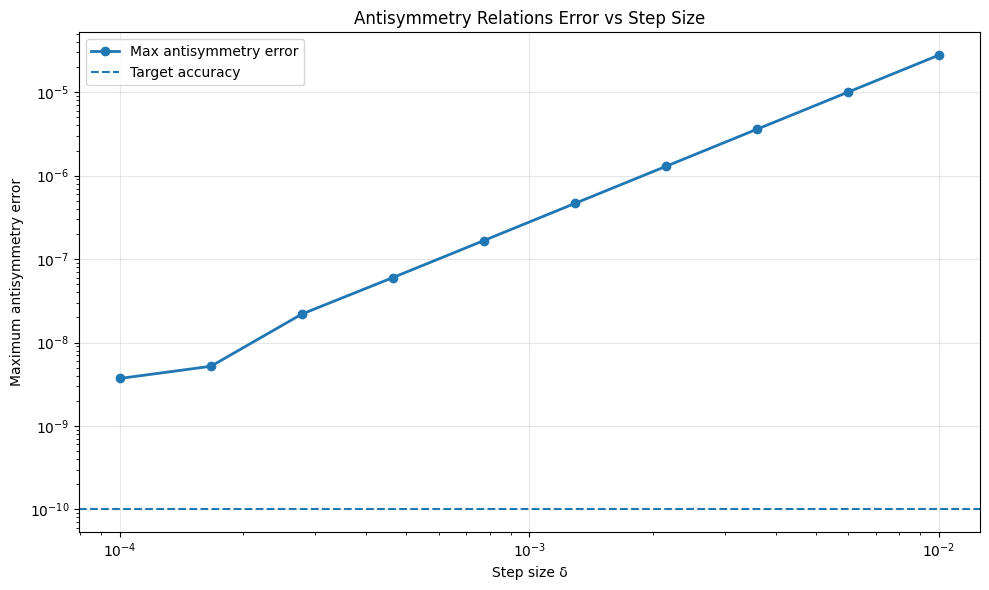

Optimal step size: δ = 0.0001
Maximum antisymmetry error at optimal δ: 3.71e-09


In [10]:
# Test effect of step size on accuracy
x0, y0, z0 = -5.0, 0.0, 0.0
step_sizes = np.logspace(-4, -2, 10)
antisym_errors = []

for d in step_sizes:
    der_d = compute_derivatives(MODEL_FUNC, parmod, ps, x0, y0, z0, delta=d)
    antisym_errors.append(get_max_antisymmetry_error(der_d))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.loglog(step_sizes, antisym_errors, marker="o", linewidth=2, label="Max antisymmetry error")
ax.axhline(1e-10, linestyle="--", label="Target accuracy")
ax.set_xlabel("Step size δ")
ax.set_ylabel("Maximum antisymmetry error")
ax.set_title("Antisymmetry Relations Error vs Step Size")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_idx = int(np.argmin(antisym_errors))
optimal_delta = float(step_sizes[optimal_idx])
print(f"Optimal step size: δ = {optimal_delta:.4f}")
print(f"Maximum antisymmetry error at optimal δ: {antisym_errors[optimal_idx]:.2e}")



<a id='practical-applications'></a>

## 6. Practical Applications


Let's explore some practical applications of directional derivatives.

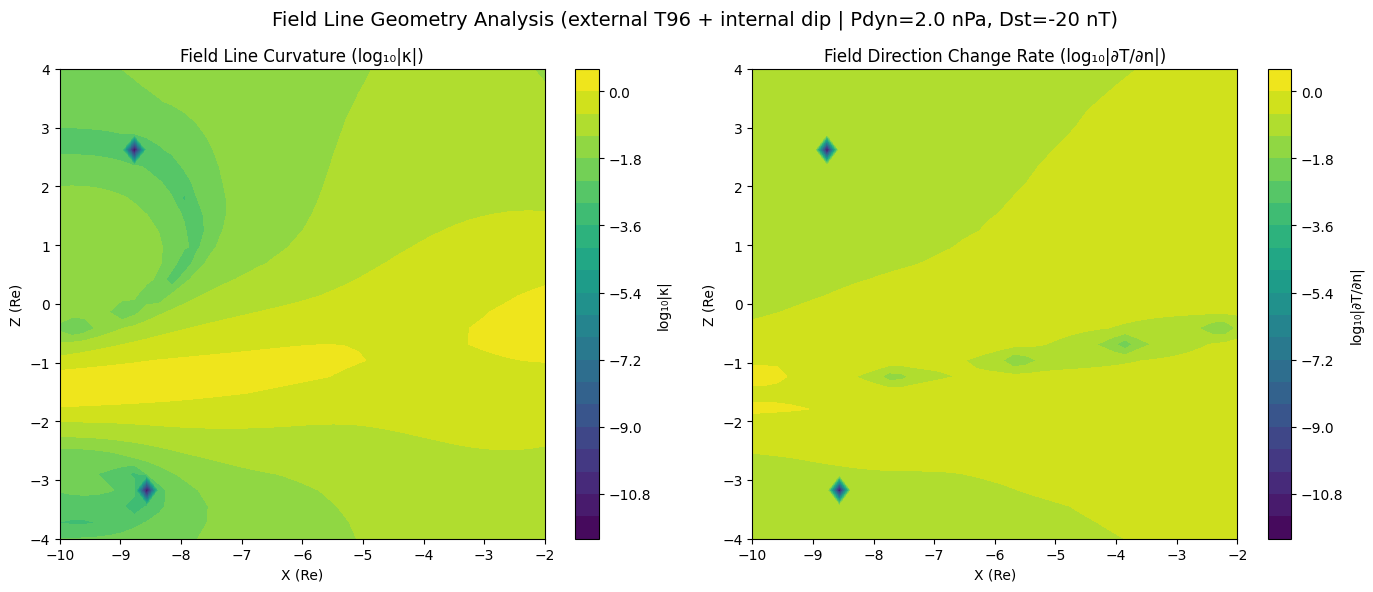

In [11]:
x_grid = np.linspace(-10, -2, 40)
z_grid = np.linspace(-4, 4, 30)
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.zeros_like(X)

x_flat = X.ravel()
y_flat = Y.ravel()
z_flat = Z.ravel()

der = compute_derivatives(MODEL_FUNC, parmod, ps, x_flat, y_flat, z_flat, delta=delta)

# Curvature (κ = (∂T/∂T)·n)
curvature = np.array(der["dT_dT_n"])

# Approximate magnitude of ∂T/∂n using available projections
dT_dn_n = np.array(der["dT_dn_n"])
dT_dn_b = np.array(der["dT_dn_b"])
dT_dn_mag = np.sqrt(dT_dn_n**2 + dT_dn_b**2)

curvature_grid = curvature.reshape(X.shape)
dT_dn_mag_grid = dT_dn_mag.reshape(X.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
c1 = ax.contourf(X, Z, np.log10(np.abs(curvature_grid) + 1e-12), levels=20)
ax.set_xlabel("X (Re)")
ax.set_ylabel("Z (Re)")
ax.set_title("Field Line Curvature (log₁₀|κ|)")
plt.colorbar(c1, ax=ax, label="log₁₀|κ|")

ax = axes[1]
c2 = ax.contourf(X, Z, np.log10(dT_dn_mag_grid + 1e-12), levels=20)
ax.set_xlabel("X (Re)")
ax.set_ylabel("Z (Re)")
ax.set_title("Field Direction Change Rate (log₁₀|∂T/∂n|)")
plt.colorbar(c2, ax=ax, label="log₁₀|∂T/∂n|")

# --- suptitle: conditional display based on MODEL ---
if MODEL == "t96":
    title = f"Field Line Geometry Analysis (external T96 | Pdyn={Pdyn} nPa, Dst={Dst} nT)"
elif MODEL == "t96+dip":
    title = f"Field Line Geometry Analysis (external T96 + internal dip | Pdyn={Pdyn} nPa, Dst={Dst} nT)"
elif MODEL == "dip":
    title = "Field Line Geometry Analysis (internal dip)"
else:
    title = f"Field Line Geometry Analysis (MODEL={MODEL})"

plt.suptitle(title, fontsize=14)
plt.tight_layout()
plt.show()

<a id='limitations'></a>

## 7. Limitations and Considerations


### Numerical Limitations


The finite difference implementation has some inherent limitations:


1. **Curved Field Lines**: For strongly curved field lines, the relationship between spatial derivatives and arc-length derivatives becomes complex.

2. **Step Size Sensitivity**: The accuracy depends on the choice of step size δ. Too small leads to numerical errors, too large leads to truncation errors.

3. **Frenet-Serret Relations**: Exact relations may not be perfectly satisfied due to finite difference approximation and frame sign issues.


### Best Practices


1. **Use default step size** (0.01 Re) for most applications

2. **Check self-components** as a measure of numerical accuracy

3. **Verify antisymmetry** for quality control

4. **Be cautious** in regions of very high curvature

In [12]:
# Demonstrate limitations in high-curvature regions (similar to ①)
x_test = np.array([-3.5, -5.0, -8.0, -12.0])
y_test = np.zeros(4)
z_test = np.array([0.5, 0.5, 0.5, 0.5])

deltas = [0.001, 0.01, 0.1]

for d in deltas:
    der_d = compute_derivatives(MODEL_FUNC, parmod, ps, x_test, y_test, z_test, delta=d)

    print(f"\nStep size δ = {d}:")
    print(f"X positions: {x_test}")
    print(f"Curvatures: {np.array(der_d['dT_dT_n'])}")
    print(f"Torsions:   {np.array(der_d['dn_dT_b'])}")

    max_err = get_max_antisymmetry_error(der_d)
    print(f"Max antisymmetry error: {max_err:.2e}")




Step size δ = 0.001:
X positions: [ -3.5  -5.   -8.  -12. ]
Curvatures: [0.51796457 0.2426936  0.00313236 0.02134096]
Torsions:   [ 1.09605480e-19  1.07753782e-18  3.78730456e-15 -1.63229345e-17]
Max antisymmetry error: 1.08e-07

Step size δ = 0.01:
X positions: [ -3.5  -5.   -8.  -12. ]
Curvatures: [0.51796252 0.2426947  0.0031326  0.02134099]
Torsions:   [ 1.09603960e-19  1.07749288e-18  3.83050972e-15 -1.63233047e-17]
Max antisymmetry error: 1.08e-05

Step size δ = 0.1:
X positions: [ -3.5  -5.   -8.  -12. ]
Curvatures: [0.51775738 0.24280463 0.         0.02134379]
Torsions:   [ 1.09382655e-19  1.07298206e-18  0.00000000e+00 -1.63477659e-17]
Max antisymmetry error: 1.08e-03


## Summary


This notebook demonstrated:


1. **The 9 Key Formulas**: Directional derivative formulas with antisymmetry validation

2. **Performance**: Significant speedup for vectorized calculations

3. **Accuracy**: Antisymmetry preservation and agreement with geometry functions for κ, τ

4. **Applications**: Field line geometry mapping and (for T96) parameter dependence


The `field_line_directional_derivatives(...)` function provides a comprehensive tool for analyzing

magnetic field line differential geometry through the 9 key formulas:

- Frenet-Serret: (∂T/∂T)·n = κ, (∂T/∂T)·b = 0, (∂n/∂T)·b = τ

- Normal: (∂T/∂n)·n, (∂T/∂n)·b, (∂n/∂n)·b

- Binormal: (∂n/∂b)·b, (∂n/∂b)·T, (∂b/∂b)·T


All formulas can be checked via `verify_antisymmetry_relations(...)`, providing a practical quality-control hook

for large grid calculations.